<a href="https://colab.research.google.com/github/jelaenas/CESISTA-KJ-DSC1105/blob/main/DSC1105_FA_4_GROUP_10_CESISTA_QUIJANO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages("devtools")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("remotes")
devtools::install_github("coatless/ucidata")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpyMZnIV/remotesdd4846e747/coatless-rpkg-ucidata-0ce8559/DESCRIPTION’ ... OK
* preparing ‘ucidata’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘ucidata_0.0.3.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(ucidata)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [63]:
data(wine)
str(wine)

'data.frame':	6497 obs. of  13 variables:
 $ fixed_acidity       : num  7.4 7.8 7.8 11.2 7.4 7.4 7.9 7.3 7.8 7.5 ...
 $ volatile_acidity    : num  0.7 0.88 0.76 0.28 0.7 0.66 0.6 0.65 0.58 0.5 ...
 $ citric_acid         : num  0 0 0.04 0.56 0 0 0.06 0 0.02 0.36 ...
 $ residual_sugar      : num  1.9 2.6 2.3 1.9 1.9 1.8 1.6 1.2 2 6.1 ...
 $ chlorides           : num  0.076 0.098 0.092 0.075 0.076 0.075 0.069 0.065 0.073 0.071 ...
 $ free_sulfur_dioxide : num  11 25 15 17 11 13 15 15 9 17 ...
 $ total_sulfur_dioxide: num  34 67 54 60 34 40 59 21 18 102 ...
 $ density             : num  0.998 0.997 0.997 0.998 0.998 ...
 $ pH                  : num  3.51 3.2 3.26 3.16 3.51 3.51 3.3 3.39 3.36 3.35 ...
 $ sulphates           : num  0.56 0.68 0.65 0.58 0.56 0.56 0.46 0.47 0.57 0.8 ...
 $ alcohol             : num  9.4 9.8 9.8 9.8 9.4 9.4 9.4 10 9.5 10.5 ...
 $ quality             : int  5 5 5 6 5 5 5 7 7 5 ...
 $ color               : Factor w/ 2 levels "Red","White": 1 1 1 1 1 1 1 1 1 1 ...


1. **(5 points). There are a couple of outliers in density, remove them.**

In [64]:
Q1 <- quantile(wine$density, 0.25)
Q3 <- quantile(wine$density, 0.75)
IQR <- Q3 - Q1

lower_bound <- Q1 - 1.5 * IQR
upper_bound <- Q3 + 1.5 * IQR

cleaned_wine <- subset(wine, density >= lower_bound & density <= upper_bound)

head(cleaned_wine)
str(cleaned_wine)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>
1,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5,Red
2,7.8,0.88,0.00,2.6,0.098,25,67,0.9968,3.20,0.68,9.8,5,Red
3,7.8,0.76,0.04,2.3,0.092,15,54,0.9970,3.26,0.65,9.8,5,Red
4,11.2,0.28,0.56,1.9,0.075,17,60,0.9980,3.16,0.58,9.8,6,Red
5,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5,Red
6,7.4,0.66,0.00,1.8,0.075,13,40,0.9978,3.51,0.56,9.4,5,Red


'data.frame':	6494 obs. of  13 variables:
 $ fixed_acidity       : num  7.4 7.8 7.8 11.2 7.4 7.4 7.9 7.3 7.8 7.5 ...
 $ volatile_acidity    : num  0.7 0.88 0.76 0.28 0.7 0.66 0.6 0.65 0.58 0.5 ...
 $ citric_acid         : num  0 0 0.04 0.56 0 0 0.06 0 0.02 0.36 ...
 $ residual_sugar      : num  1.9 2.6 2.3 1.9 1.9 1.8 1.6 1.2 2 6.1 ...
 $ chlorides           : num  0.076 0.098 0.092 0.075 0.076 0.075 0.069 0.065 0.073 0.071 ...
 $ free_sulfur_dioxide : num  11 25 15 17 11 13 15 15 9 17 ...
 $ total_sulfur_dioxide: num  34 67 54 60 34 40 59 21 18 102 ...
 $ density             : num  0.998 0.997 0.997 0.998 0.998 ...
 $ pH                  : num  3.51 3.2 3.26 3.16 3.51 3.51 3.3 3.39 3.36 3.35 ...
 $ sulphates           : num  0.56 0.68 0.65 0.58 0.56 0.56 0.46 0.47 0.57 0.8 ...
 $ alcohol             : num  9.4 9.8 9.8 9.8 9.4 9.4 9.4 10 9.5 10.5 ...
 $ quality             : int  5 5 5 6 5 5 5 7 7 5 ...
 $ color               : Factor w/ 2 levels "Red","White": 1 1 1 1 1 1 1 1 1 1 ...


2. **(7 points). Make a scatterplot of wine type as a function of total sulfur dioxide. Add a loess smoother and a logistic regression smoother. Comment on similarities or differences. (Note: To do this, you will need to change wine type from white/red to 0/1.)**

In [65]:

cleaned_wine <- cleaned_wine %>%
  mutate(color_binary = ifelse(color == "White", 1, 0))


table(cleaned_wine$color, cleaned_wine$color_binary)

       
           0    1
  Red   1599    0
  White    0 4895

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_smooth()`).”


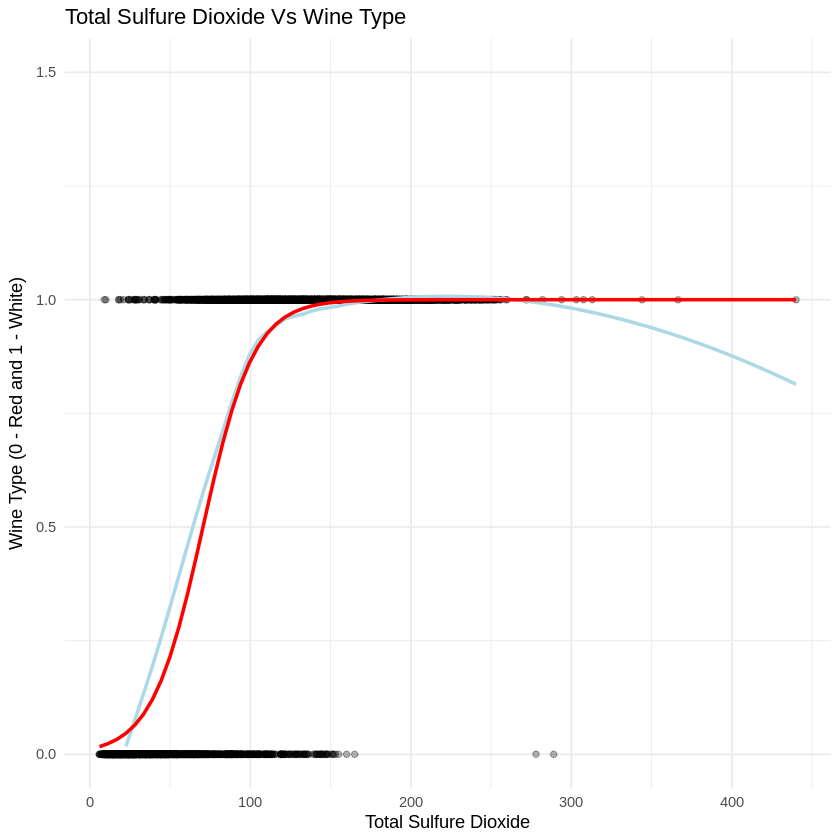

In [74]:
ggplot(cleaned_wine, aes(x = total_sulfur_dioxide, y = color_binary)) +
  geom_point(alpha = 0.3) +

  geom_smooth(method = "loess", col = "lightblue", se = FALSE) +

  geom_smooth(method = "glm",
              method.args = list(family = "binomial"),
              col = "red", se = FALSE) +

  ylim(0, 1.5) +
  theme_minimal() +  labs(
  title = "Total Sulfure Dioxide Vs Wine Type",
  x = "Total Sulfure Dioxide",
  y = "Wine Type (0 - Red and 1 - White)",
)

 Comment on similarities or differences: Both wine types can have a total sulfur dioxide of 0. However, white wine can have up to 400+ in total sulfur dioxide, while red wine only has up to less than 300. Majority of total sulfur dioxie of white wine is from 0 to ~250, and majority of total sulfur dioxie of red wine is from 0 to ~150.

3. **(7 points). Make a scatterplot of wine type as a function of density. Add a loess smoother and a logistic regression smoother. Comment on similarities or differences.**

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


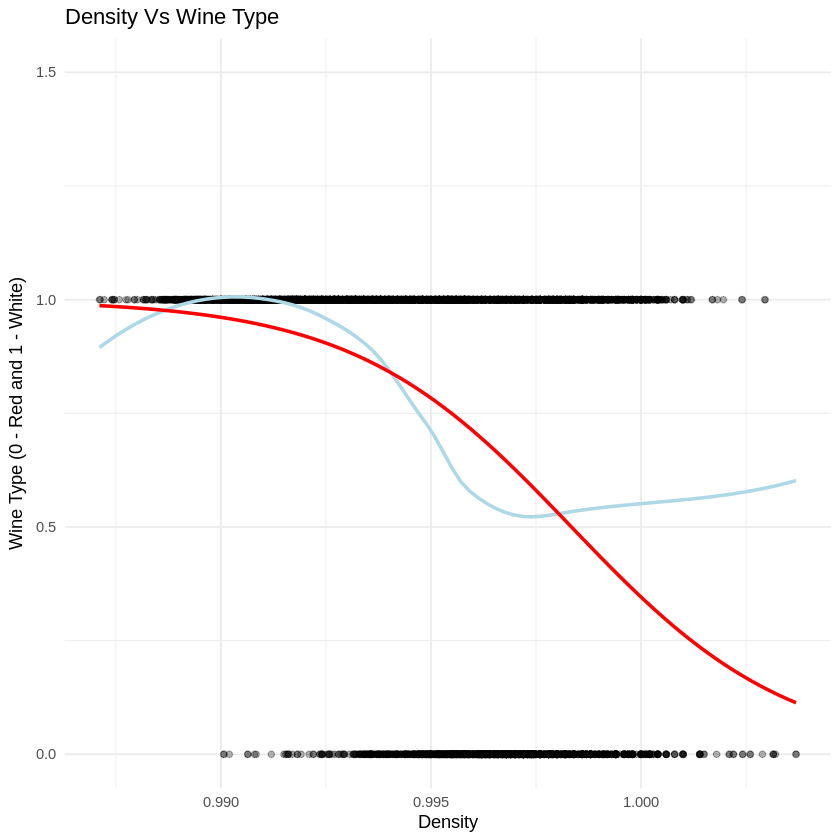

In [75]:
ggplot(cleaned_wine, aes(x = density, y = color_binary)) +
  geom_point(alpha = 0.3) +

  geom_smooth(method = "loess", col = "lightblue", se = FALSE) +

  geom_smooth(method = "glm",
              method.args = list(family = "binomial"),
              col = "red", se = FALSE) +

  ylim(0, 1.5) +
  theme_minimal() +  labs(
  title = "Density Vs Wine Type",
  x = "Density",
  y = "Wine Type (0 - Red and 1 - White)",
)


 Comment on similarities or differences: The density of both wine types can go up to more than 1. While, the smallest density of red wine is ~0.990 and the smallest density of white wine is 0. Majority of density of white wine is from 0 to ~1, and majority of density of red wine  from 0.990 to ~1.

4. **(8 points). Fit two logistic regression models: one with no interaction between density and total sulfur dioxide and one with an interaction between density and total sulfur dioxide. Make two coplots for each model showing the fits. For each model, you should have one coplot of wine type as a function of density conditioned on total sulfur dioxide, and one with wine type as a function of total sulfur dioxide conditioned on density.**

In [ ]:
model_no_interaction <- glm(color ~ density + total_sulfur_dioxide, family = "binomial", data = cleaned_wine)
model_with_interaction <- glm(color ~ density * total_sulfur_dioxide, family = "binomial", data = cleaned_wine)

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


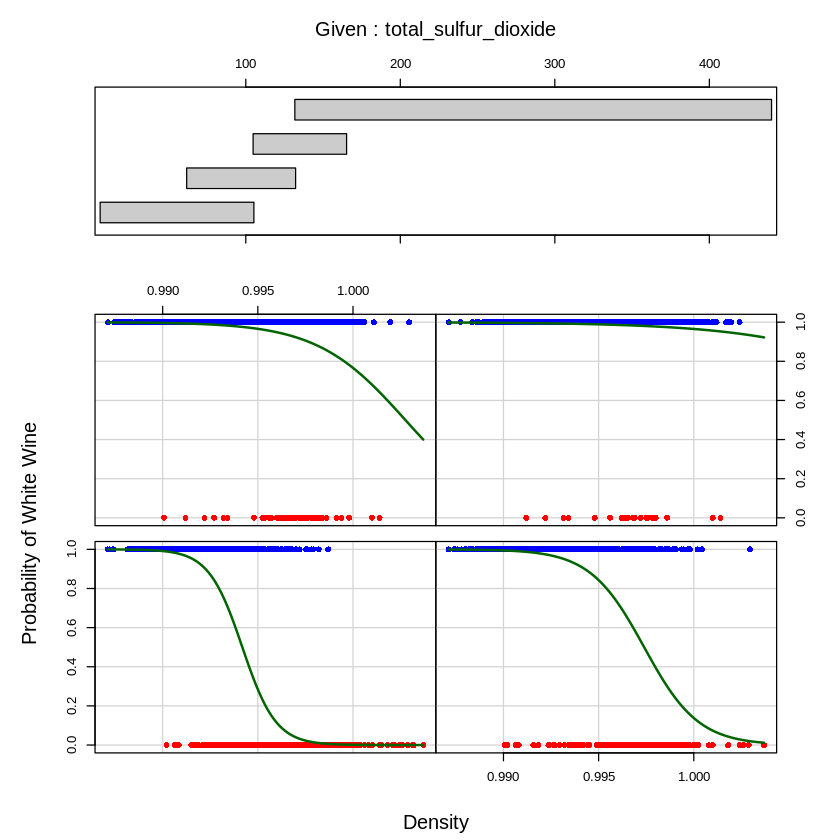

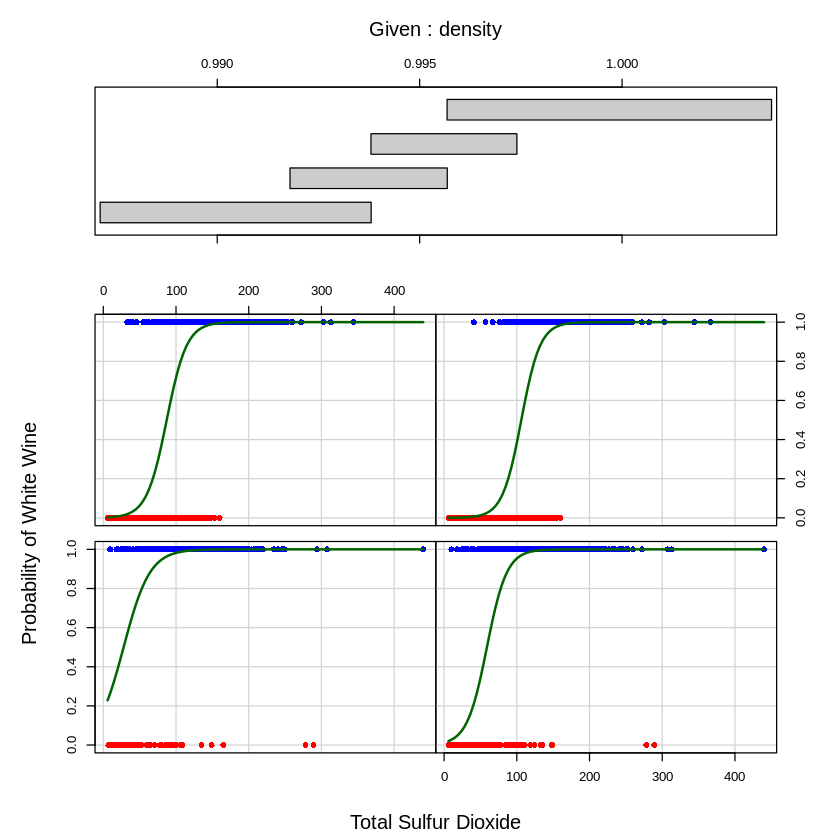

In [80]:
# Coplot (No interaction model): wine type vs density conditioned on total_sulfur_dioxide
coplot(color_binary ~ density | total_sulfur_dioxide, data = cleaned_wine,
       panel = function(x, y, ...) {
         points(x[y == 0], y[y == 0], col = "red", pch = 16) # Red wines
         points(x[y == 1], y[y == 1], col = "blue", pch = 16) # White wines
         fit <- glm(y ~ x, family = "binomial")
         curve(predict(fit, data.frame(x = x), type = "response"),
               add = TRUE, col = "darkgreen", lwd = 2)
       }, xlab = "Density", ylab = "Probability of White Wine", number = 4)

# Coplot (No interaction model): color vs total_sulfur_dioxide conditioned on density
coplot(color_binary ~ total_sulfur_dioxide | density, data = cleaned_wine,
       panel = function(x, y, ...) {
         points(x[y == 0], y[y == 0], col = "red", pch = 16)
         points(x[y == 1], y[y == 1], col = "blue", pch = 16)
         fit <- glm(y ~ x, family = "binomial")
         curve(predict(fit, data.frame(x = x), type = "response"),
               add = TRUE, col = "darkgreen", lwd = 2)
       }, xlab = "Total Sulfur Dioxide", ylab = "Probability of White Wine", number = 4)

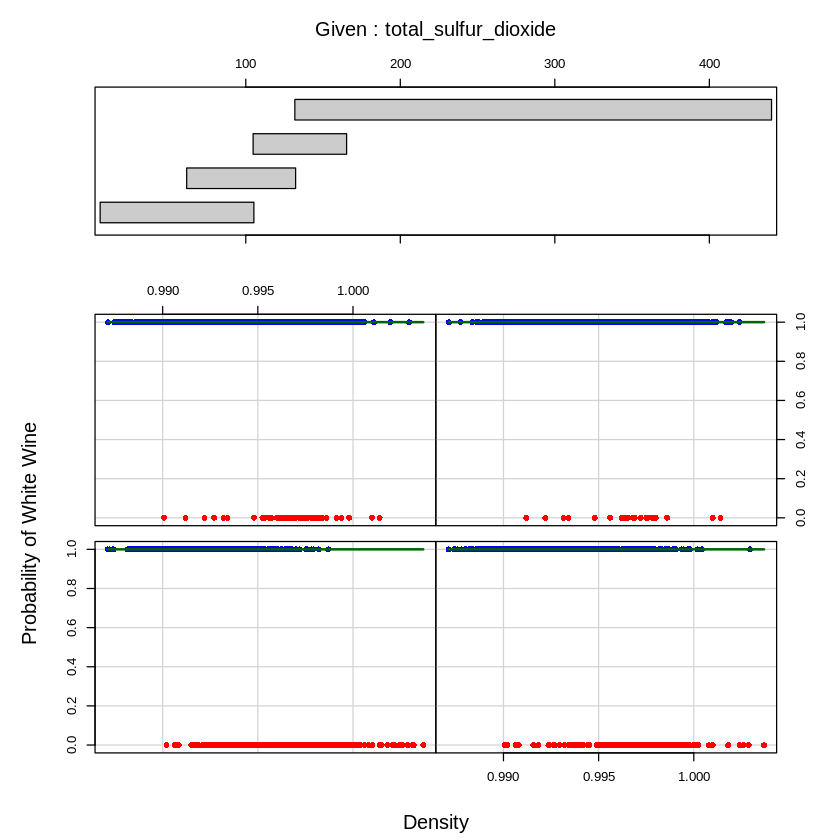

In [82]:
# Coplot (With Interaction Model) : wine type vs density conditioned on total_sulfur_dioxide

coplot(color_binary ~ density | total_sulfur_dioxide, data = cleaned_wine,
       panel = function(x, y, ...) {
         points(x[y == 0], y[y == 0], col = "red", pch = 16)
         points(x[y == 1], y[y == 1], col = "blue", pch = 16)
         curve(predict(model_with_interaction,
                       newdata = data.frame(density = x,
                                            total_sulfur_dioxide = mean(x)),
                       type = "response"),
               add = TRUE, col = "darkgreen", lwd = 2)
       }, xlab = "Density", ylab = "Probability of White Wine", number = 4)

# Coplot (With Interaction Model) : color vs total_sulfur_dioxide conditioned on density

coplot(color_binary ~ density | total_sulfur_dioxide, data = cleaned_wine,
       panel = function(x, y, ...) {
         points(x[y == 0], y[y == 0], col = "red", pch = 16)
         points(x[y == 1], y[y == 1], col = "blue", pch = 16)
         curve(predict(model_with_interaction,
                       newdata = data.frame(density = x,
                                            total_sulfur_dioxide = mean(x)),
                       type = "response"),
               add = TRUE, col = "darkgreen", lwd = 2)
       }, xlab = "Density", ylab = "Probability of White Wine", number = 4)

5. **(3 points). Comment briefly on what these plots tell you about the relationships among the three variables.**

- The coplots suggest that density and total sulfur dioxide are both significant predictors of wine type, however their effects on wine type do not necessarily depend on the other variable. As total sulfur dioxide increases, the likelihood of it being white wine also increases, which can be seen through the varying density levels. Density can also help whith determining if a wine is red or white (as white wine can have density as small as 0 and red wine also has density as small as 0.990) however this effect varies depending on total sulfur dioxide. This means that there is possibility of an interaction effect where the influence of density on wine type, can vary depending on the value of total sulfur dioxide. Overall, the plots suggest that a model with interaction is a better fit.